In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#https://www.kaggle.com/datasets/camnugent/california-housing-prices/data

In [3]:
df = pd.read_csv("21-housing.csv")

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [10]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

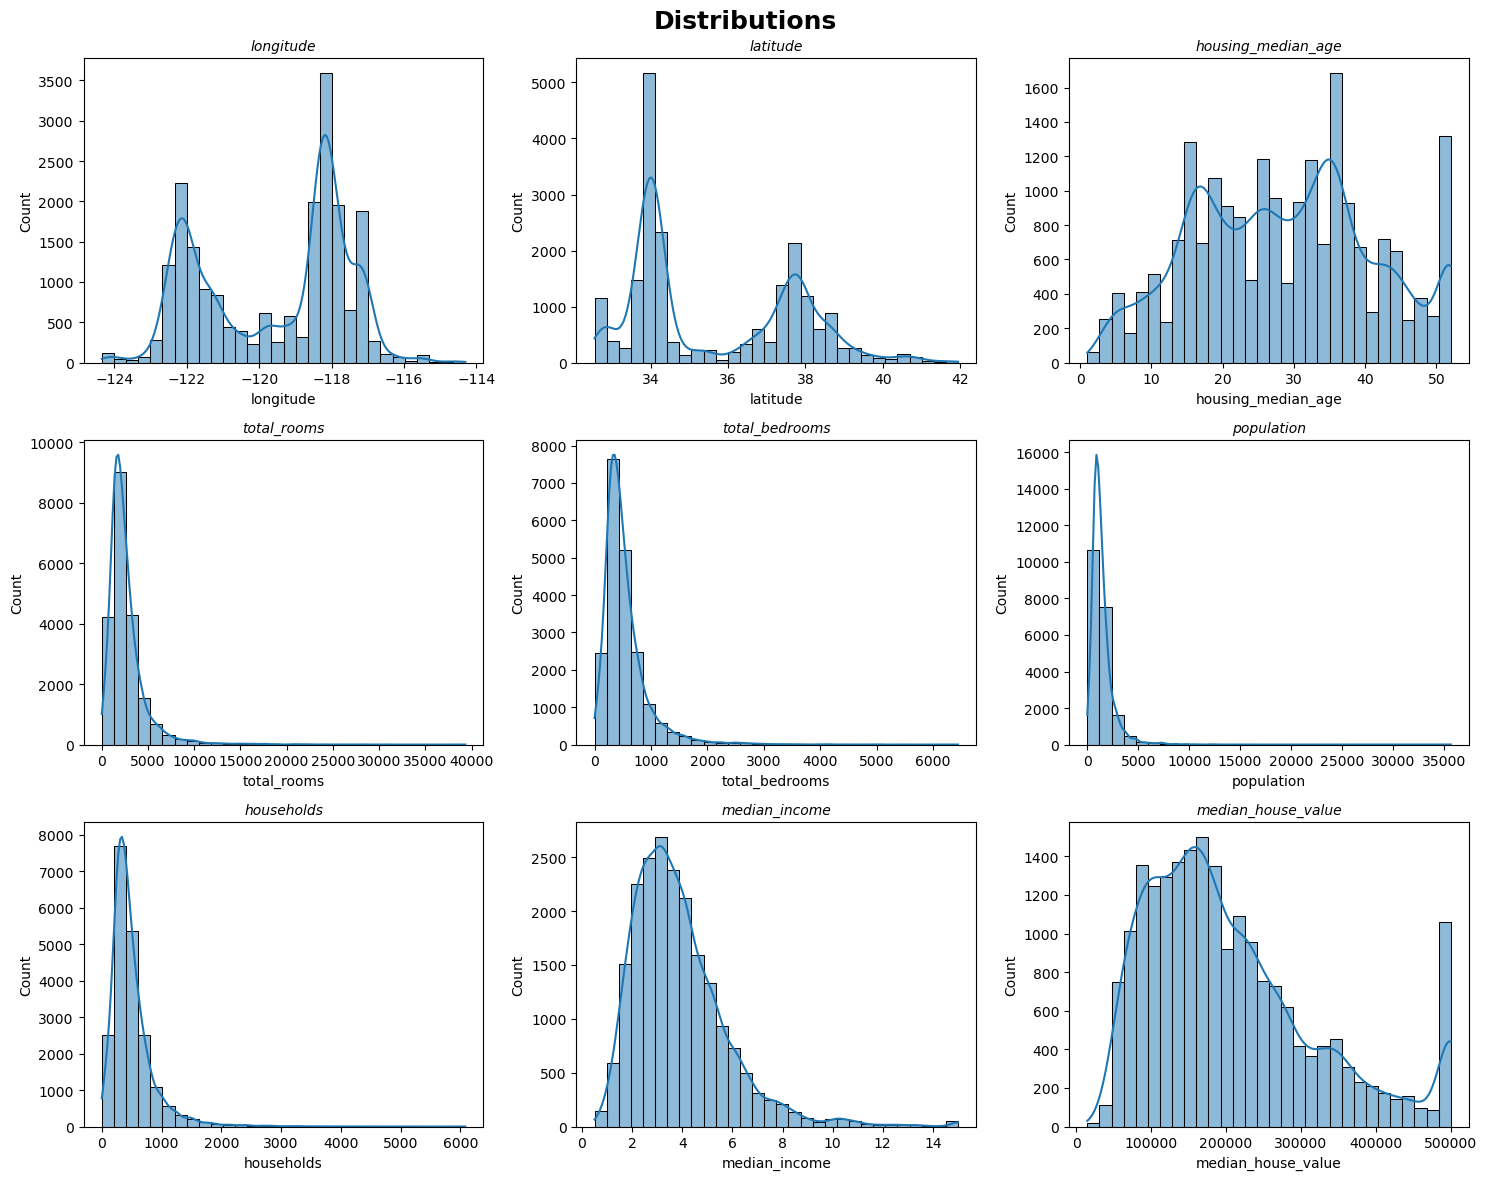

In [11]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,12))
fig.suptitle("Distributions", fontsize=18, fontweight="bold")

for i, col in enumerate(columns):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    sns.histplot(data=df, x=col, kde=True, ax=ax, bins=30)
    ax.set_title(col, fontsize=10, fontstyle="italic")

plt.tight_layout()    
plt.show()    

In [12]:
df.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [13]:
df.select_dtypes("float64", "int64").columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [14]:
def find_outlier_iqr(df, threshold = 1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_summary[col] = {
            "outlier_count": outliers.shape[0],
            "outliers_percentage": 100 * outliers.shape[0] / df.shape[0],
            "lower_bound": lower_bound,
            "upper_bound": upper_bound
        }

    return pd.DataFrame(outlier_summary)

In [15]:
find_outlier_iqr(df, threshold=1.5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outlier_count,0.000,0.00,0.0,1287.000000,1271.000000,1196.000000,1220.000000,681.000000,1071.000000
outliers_percentage,0.000,0.00,0.0,6.235465,6.157946,5.794574,5.910853,3.299419,5.188953
lower_bound,-127.485,28.26,-10.5,-1102.625000,-230.500000,-620.000000,-207.500000,-0.706375,-98087.500000
upper_bound,-112.325,43.38,65.5,5698.375000,1173.500000,3132.000000,1092.500000,8.013025,482412.500000


In [16]:
def remove_outliers_from_column(df, target_col, threshold=1.5):

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [17]:
print("original data shape: ", df.shape)

df_target_clean = remove_outliers_from_column(df, "median_house_value")
print("only target column cleaning shape: ", df_target_clean.shape)

original data shape:  (20640, 10)
only target column cleaning shape:  (19569, 10)


In [18]:
df_target_clean.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [19]:
df_target_clean.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19569.000000,19569.000000,19569.000000,19569.000000,19369.000000,19569.000000,19569.000000,19569.000000,19569.000000
mean,-119.562786,35.654159,28.352752,2619.977260,539.893335,1442.788952,501.394859,3.665568,190852.301906
std,2.005764,2.151007,12.497772,2183.419302,422.650225,1145.011369,383.396308,1.557927,95438.555669
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.760000,33.930000,18.000000,1438.000000,297.000000,797.000000,282.000000,2.522700,116200.000000
50%,-118.510000,34.270000,28.000000,2110.000000,437.000000,1181.000000,411.000000,3.441200,173200.000000
75%,-117.990000,37.730000,37.000000,3123.000000,648.000000,1749.000000,606.000000,4.572100,246700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,482200.000000


In [20]:
df_target_clean.loc[:, "total_bedrooms"] = df_target_clean["total_bedrooms"].fillna(df_target_clean["total_bedrooms"].median())

In [21]:
df_target_clean.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000
mean,-119.562786,35.654159,28.352752,2619.977260,538.841739,1442.788952,501.394859,3.665568,190852.301906
std,2.005764,2.151007,12.497772,2183.419302,420.612109,1145.011369,383.396308,1.557927,95438.555669
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.760000,33.930000,18.000000,1438.000000,299.000000,797.000000,282.000000,2.522700,116200.000000
50%,-118.510000,34.270000,28.000000,2110.000000,437.000000,1181.000000,411.000000,3.441200,173200.000000
75%,-117.990000,37.730000,37.000000,3123.000000,645.000000,1749.000000,606.000000,4.572100,246700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,482200.000000


In [22]:
df_target_clean.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [23]:
df_target_clean["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     8552
INLAND        6519
NEAR OCEAN    2419
NEAR BAY      2074
ISLAND           5
Name: count, dtype: int64

In [24]:
df_target_clean = pd.get_dummies(df_target_clean, columns=["ocean_proximity"], drop_first=True, dtype=int)

In [25]:
df_target_clean

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1,0,0,0


# Independent & Dependent Features

In [26]:
X = df_target_clean.drop("median_house_value", axis=1)
y = df_target_clean["median_house_value"]

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [29]:
X_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [30]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [31]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)

    return mae, rmse, r2_square

In [32]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Adaboost Regressor": AdaBoostRegressor(),
    "Gradient Boost Regressor": GradientBoostingRegressor(),
    "XGBoost Regressor": XGBRegressor()
}

In [33]:
raw_results = []

for i in range(len(models)):
    name = list(models.keys())[i]
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    mae_train, rmse_train, r2_train = evaluate_model(y_train, y_train_pred)
    mae_test, rmse_test, r2_test = evaluate_model(y_test, y_test_pred)

    raw_results.append({
        "Model": name,
        "Train MAE": mae_train,
        "Train RMSE": rmse_train,
        "Train R2": r2_train,
        "Test MAE": mae_test,
        "Test RMSE": rmse_test,
        "Test R2": r2_test
    })
df_untransformed = pd.DataFrame(raw_results)

In [34]:
df_untransformed

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Linear Regression,43858.387482,59377.105929,0.610424,43594.363863,58769.547257,0.626330
1,Lasso,43859.008585,59377.144669,0.610423,43594.668780,58768.462304,0.626343
2,Ridge,43864.677315,59381.168680,0.610370,43597.142912,58763.961258,0.626401
3,K Neighbors Regressor,56469.600219,72182.637452,0.424268,69873.333504,88529.857964,0.152063
4,Decision Tree,0.000000,0.000000,1.000000,41498.961165,61813.617064,0.586617
5,Random Forest Regressor,11059.077184,16448.559846,0.970104,29700.349518,43763.316812,0.792793
6,Adaboost Regressor,67495.555709,77489.051867,0.336509,67447.698096,78041.148447,0.341082
7,Gradient Boost Regressor,33890.098914,47359.963614,0.752157,35162.871975,49306.235965,0.736981
8,XGBoost Regressor,17501.127481,24400.366805,0.934212,28663.591162,42221.553326,0.807135


# Hyperparameter Tuning

In [35]:
xgboost_params = {
    "learning_rate": [0.1, 0.01],
    "max_depth": [5,8,12,20,30],
    "n_estimators": [100,200,300,500],
    "colsample_bytree": [0.3, 0.4, 0.5, 0.7, 1]
}

In [37]:
from sklearn.model_selection import RandomizedSearchCV

In [40]:
random_cv = RandomizedSearchCV(estimator=XGBRegressor(), param_distributions=xgboost_params, cv=5)
random_cv.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.3, 0.4, 0.5, 0.7,
                                                             1],
                                        'learning_rate': [0.1, 0.01],
                                        'max_depth': [5, 8, 12, 20, 30],
                                        'n_estimators': [100, 200, 300, 500]})

In [41]:
random_cv.best_params_

{'n_estimators': 200,
 'max_depth': 5,
 'learning_rate': 0.1,
 'colsample_bytree': 1}

In [63]:
model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, colsample_bytree=1)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, ...)

In [64]:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)


    print(list(models.keys())[i])
    print("Model performance for Training Set")
    print("Root Mean Squared Error: ", model_train_rmse)
    print("Mean Absolute Error: ", model_train_mae)
    print("R2 Score: ", model_train_r2)

    print("-" * 30)
    
    print("Model performance for Test Set")
    print("Root Mean Squared Error: ", model_test_rmse)
    print("Mean Absolute Error: ", model_test_mae)
    print("R2 Score: ", model_test_r2)

XGBoost Regressor
Model performance for Training Set
Root Mean Squared Error:  33468.53920013779
Mean Absolute Error:  23476.931609541538
R2 Score:  0.8762263923025867
------------------------------
Model performance for Test Set
Root Mean Squared Error:  42095.35701562016
Mean Absolute Error:  28943.631483137455
R2 Score:  0.8082866381846286


# Transformation

In [65]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
6487,-118.00,34.10,34.0,2249.0,460.0,1544.0,441.0,3.4005,1,0,0,0
15385,-116.95,33.31,16.0,2921.0,639.0,1838.0,540.0,2.2393,0,0,0,0
12111,-117.34,34.02,28.0,2683.0,708.0,2047.0,636.0,2.2750,1,0,0,0
10811,-117.92,33.64,24.0,2539.0,695.0,1623.0,611.0,3.0708,0,0,0,0
3290,-122.66,39.03,27.0,1446.0,329.0,594.0,255.0,1.1650,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6857,-118.16,34.06,27.0,1675.0,274.0,785.0,275.0,5.8280,0,0,0,0
17117,-122.16,37.48,36.0,2238.0,479.0,1949.0,457.0,2.3769,0,0,1,0
2726,-115.54,32.79,30.0,752.0,194.0,733.0,186.0,1.6607,1,0,0,0
8422,-118.35,33.93,31.0,2746.0,697.0,1973.0,598.0,3.5139,0,0,0,0


In [66]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((13698, 12), (5871, 12), (13698,), (5871,))

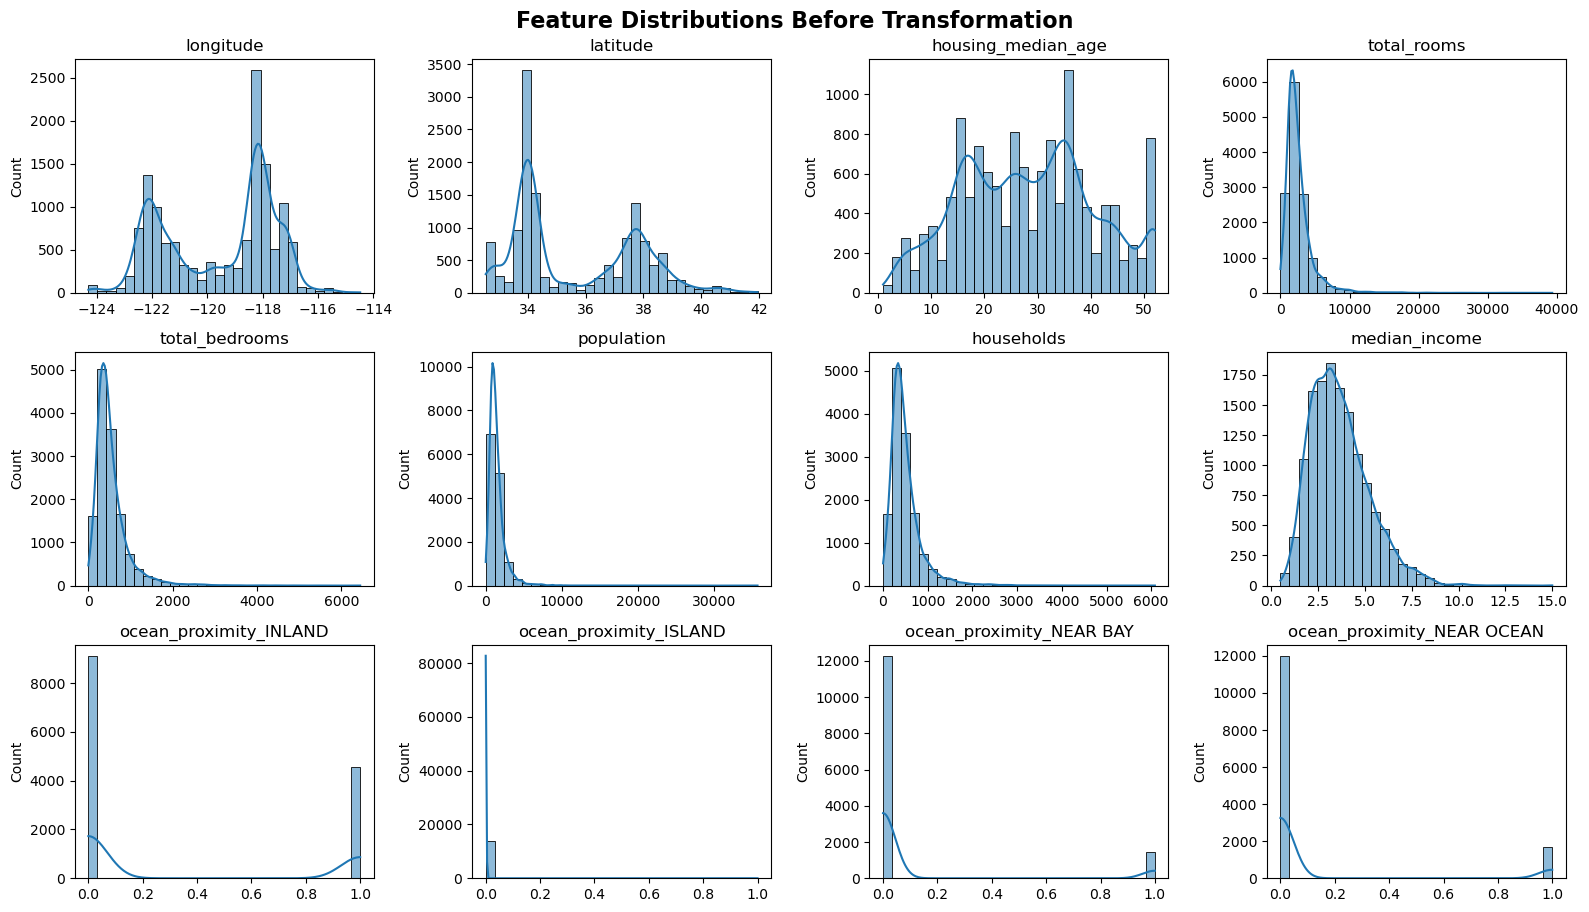

In [67]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16,12))
axes = axes.flatten()

for i, col in enumerate(X_train.columns):
    sns.histplot(X_train[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")


for j in range(len(X_train.columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Feature Distributions Before Transformation", fontsize=16, fontweight='bold')
plt.tight_layout()    
plt.show()    

In [68]:
transform_column = [col for col in X_train.columns if not col.startswith("ocean")]

In [69]:
transform_column

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

In [70]:
from sklearn.preprocessing import PowerTransformer

In [71]:
pt_X = PowerTransformer(method="yeo-johnson")

X_train_transformed = pt_X.fit_transform(X_train[transform_column])
X_test_transformed = pt_X.transform(X_test[transform_column])

In [72]:
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=transform_column, index=X_train.index)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=transform_column, index=X_test.index)

In [73]:
X_train_transformed_df.sample(4)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
15934,-2.442491e-15,1.024084,1.792795,-0.162504,-0.332829,-0.147432,-0.249143,0.234488
8600,1.026956e-15,-0.818479,-0.711541,-1.328909,-1.448317,-1.518242,-1.411654,1.409942
12443,4.385381e-15,-1.040968,-0.796878,-0.330580,-0.187809,1.685368,-0.561568,-1.565332
20284,2.498002e-16,-0.621115,0.786679,0.580879,0.848977,1.321939,0.859683,-0.374150


In [74]:
X_test_transformed_df.sample(4)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
11395,1.443290e-15,-0.911258,-0.460469,0.700052,0.008421,0.267672,0.208997,1.668868
2475,-4.440892e-16,0.536192,-0.796878,-0.860592,-0.880251,-0.615003,-0.885304,-0.997923
7419,1.193490e-15,-0.760051,1.225517,-0.017031,0.077721,0.560145,0.094503,-0.864583
18914,-2.303713e-15,1.162109,-1.814856,1.331216,-0.050264,1.341792,0.864194,1.179057


In [75]:
untransformed_columns = [col for col in X_train.columns if col.startswith("ocean")]

X_train_untransformed = X_train[untransformed_columns]
X_test_untransformed = X_test[untransformed_columns]

X_train_final = pd.concat([X_train_transformed_df, X_train_untransformed], axis=1)
X_test_final = pd.concat([X_test_transformed_df, X_test_untransformed], axis=1)

In [76]:
X_train_final.sample(4)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
4312,1.054712e-15,-0.677296,0.637451,-1.490838,-1.179836,-1.361515,-1.435702,0.177959,0,0,0,0
3340,-2.636780e-15,1.361200,-0.460469,-1.194247,-1.245986,-1.244750,-1.403725,0.006710,1,0,0,0
4179,1.165734e-15,-0.677296,0.637451,-0.565137,-0.124627,0.625771,-0.048227,-0.725568,0,0,0,0
16305,-1.637579e-15,1.117128,-1.058596,0.305407,0.421987,0.334511,0.530895,0.114539,1,0,0,0


In [77]:
X_test_final.sample(4)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
5427,9.714451e-16,-0.721618,0.486589,0.470154,1.158252,1.216045,1.291304,-0.939196,0,0,0,0
3762,1.026956e-15,-0.627313,1.080628,-0.325096,-0.121181,0.156349,0.010830,-0.117105,0,0,0,0
2534,-2.192690e-15,1.573964,0.486589,-0.079083,-0.395933,-0.328342,-0.387903,-0.424760,1,0,0,0
143,-2.303713e-15,1.047739,1.652697,0.386671,0.437440,0.056634,0.397533,-0.388737,0,0,1,0


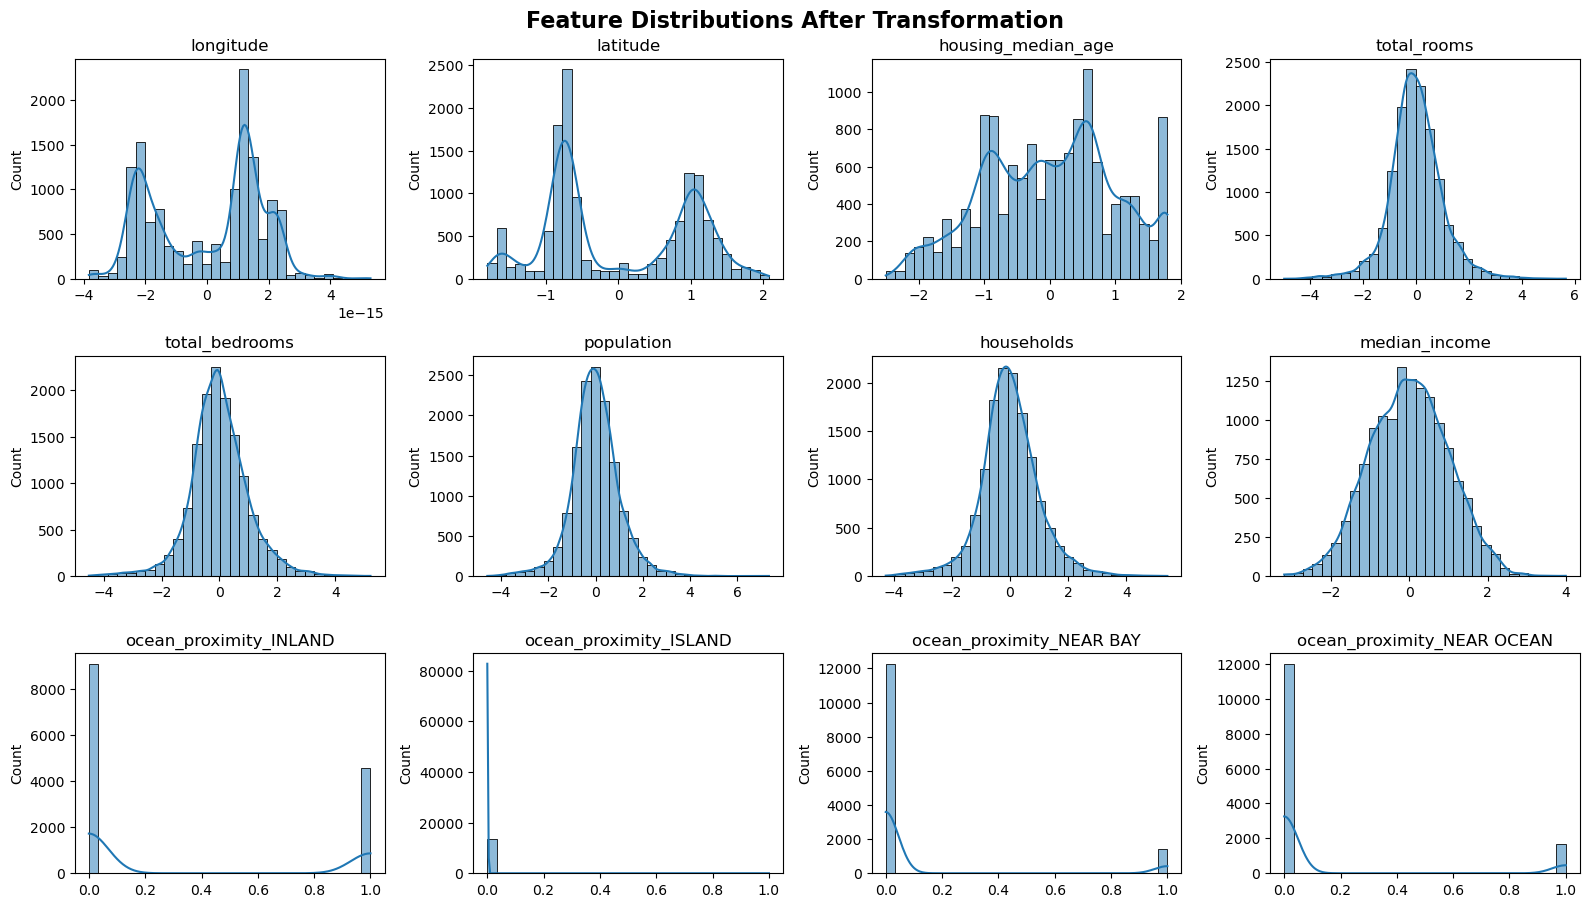

In [78]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16,12))
axes = axes.flatten()

for i, col in enumerate(X_train_final.columns):
    sns.histplot(X_train_final[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")


for j in range(len(X_train.columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Feature Distributions After Transformation", fontsize=16, fontweight='bold')
plt.tight_layout()    
plt.show() 

In [ ]:
# Transformation for target feature

In [79]:
from scipy.stats import boxcox
y_train_transformed, lambda_y = boxcox(y_train)

In [80]:
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [81]:
transformed_results = []

for i in range(len(models)):
    name = list(models.keys())[i]
    model = list(models.values())[i]
    model.fit(X_train_final, y_train_transformed)

    y_train_pred = inverse_boxcox(model.predict(X_train_final), lambda_y)
    y_test_pred = inverse_boxcox(model.predict(X_test_final), lambda_y)

    mae_train, rmse_train, r2_train = evaluate_model(y_train, y_train_pred)
    mae_test, rmse_test, r2_test = evaluate_model(y_test, y_test_pred)

    transformed_results.append({
        "Model": name,
        "Train MAE (Transformed)": mae_train,
        "Train RMSE (Transformed)": rmse_train,
        "Train R2 (Transformed)": r2_train,
        "Test MAE (Transformed)": mae_test,
        "Test RMSE (Transformed)": rmse_test,
        "Test R2 (Transformed)": r2_test
    })
df_transformed = pd.DataFrame(transformed_results)    

In [82]:
df_transformed[["Model", "Train R2 (Transformed)", "Test R2 (Transformed)"]]

,Model,Train R2 (Transformed),Test R2 (Transformed)
0,Linear Regression,0.612556,0.627829
1,Lasso,0.497792,0.509154
2,Ridge,0.612479,0.627841
3,K Neighbors Regressor,0.771218,0.664750
4,Decision Tree,1.000000,0.604461
5,Random Forest Regressor,0.966256,0.791203
6,Adaboost Regressor,0.533419,0.531016
7,Gradient Boost Regressor,0.737888,0.723276
8,XGBoost Regressor,0.923294,0.803638


In [83]:
df_untransformed[["Model", "Train R2", "Test R2"]]

,Model,Train R2,Test R2
0,Linear Regression,0.610424,0.626330
1,Lasso,0.610423,0.626343
2,Ridge,0.610370,0.626401
3,K Neighbors Regressor,0.424268,0.152063
4,Decision Tree,1.000000,0.586617
5,Random Forest Regressor,0.970104,0.792793
6,Adaboost Regressor,0.336509,0.341082
7,Gradient Boost Regressor,0.752157,0.736981
8,XGBoost Regressor,0.934212,0.807135


# In Conclusion

Feature and target transformations had mixed effects across models. K Neighbors and Adaboost Regressors showed clear improvements, especially in test R² scores. Tree-based models like Random Forest and XGBoost remained largely unaffected. For linear models, the impact was minimal. Overall, transformations can help—but their benefit depends heavily on the model type.